<a href="https://colab.research.google.com/github/YHFTF/CV_HW-3/blob/main/CV_HW_3(B).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

문제 B

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from torch.utils.data import DataLoader, TensorDataset

# 1. 데이터 준비 (make_moons: 비선형 분류)
x_data, y_data = make_moons(n_samples=1000, noise=0.1, random_state=42)
x_tensor = torch.FloatTensor(x_data)
y_tensor = torch.LongTensor(y_data)
dataset = TensorDataset(x_tensor, y_tensor)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# 2. 실험용 모델 정의
class ActivationExpModel(nn.Module):
    def __init__(self, act_fn_name='ReLU'):
        super(ActivationExpModel, self).__init__()

        # 활성화 함수 선택
        if act_fn_name == 'ReLU':
            self.act = nn.ReLU()
        elif act_fn_name == 'LeakyReLU':
            self.act = nn.LeakyReLU(0.01)
        elif act_fn_name == 'Sigmoid':
            self.act = nn.Sigmoid()

        # 레이어 구성
        # 입력(2) -> 은닉1(128) -> 은닉2(64) -> 출력(2)의 MLP 구조
        self.layer1 = nn.Linear(2, 128)
        self.layer2 = nn.Linear(128, 64)
        self.layer3 = nn.Linear(64, 2)

        # 가중치 초기화: Dead ReLU 유도를 위해 아주 작은 값 사용
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0, std=0.01) # 매우 작은 std
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # 레이어별 출력을 기록하기 위해 중간값 저장
        self.a1 = self.act(self.layer1(x))
        self.a2 = self.act(self.layer2(self.a1))
        out = self.layer3(self.a2)
        return out

# 3. 실험 실행 함수
def run_experiment_b(act_name):
    print(f"실험 B 시작: 활성화 함수 = {act_name}")
    model = ActivationExpModel(act_name)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    history = {'acc': [], 'dead_ratio': [], 'activations': []}

    for epoch in range(200): # 200회
        model.train()
        correct = 0
        total = 0

        # Dead ReLU 측정을 위한 임시 리스트
        epoch_dead_counts = []

        for inputs, targets in loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

            # [Dead ReLU 계산] 출력이 0 이하인 뉴런 비율 (ReLU 기준)
            with torch.no_grad():
                # 각 레이어별로 값이 0 이하인 뉴런 비율 계산
                dead1 = (model.a1 <= 0).float().mean().item()
                dead2 = (model.a2 <= 0).float().mean().item()
                epoch_dead_counts.append([dead1, dead2])

        acc = 100. * correct / total
        history['acc'].append(acc)
        history['dead_ratio'].append(np.mean(epoch_dead_counts, axis=0))

        # 학습 초/중/후반의 활성화 값 분포 저장을 위해 (Epoch 0, 100, 199)
        if epoch in [0, 100, 199]:
            history['activations'].append({
                'epoch': epoch,
                'layer1': model.a1.detach().cpu().numpy(),
                'layer2': model.a2.detach().cpu().numpy()
            })

    return history

# 세 가지 활성화 함수에 대해 실험 수행
results = {name: run_experiment_b(name) for name in ['ReLU', 'LeakyReLU', 'Sigmoid']}

실험 B 시작: 활성화 함수 = ReLU
실험 B 시작: 활성화 함수 = LeakyReLU
실험 B 시작: 활성화 함수 = Sigmoid


시각화 코드 (히트맵 및 활성화 분포)

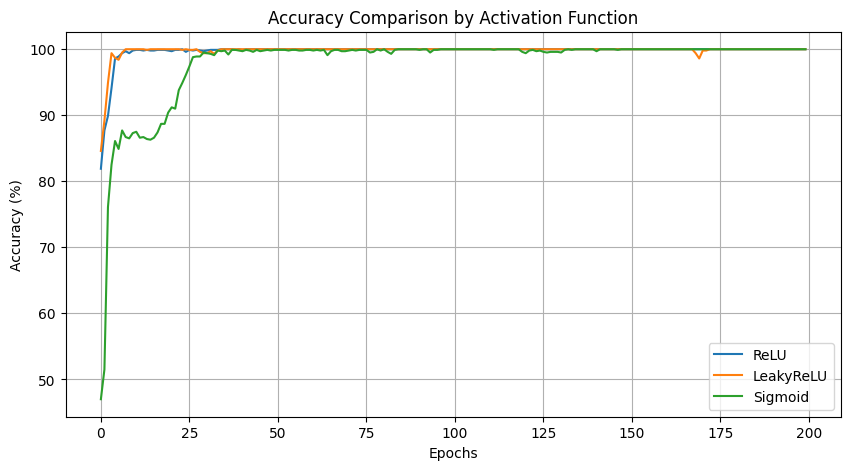

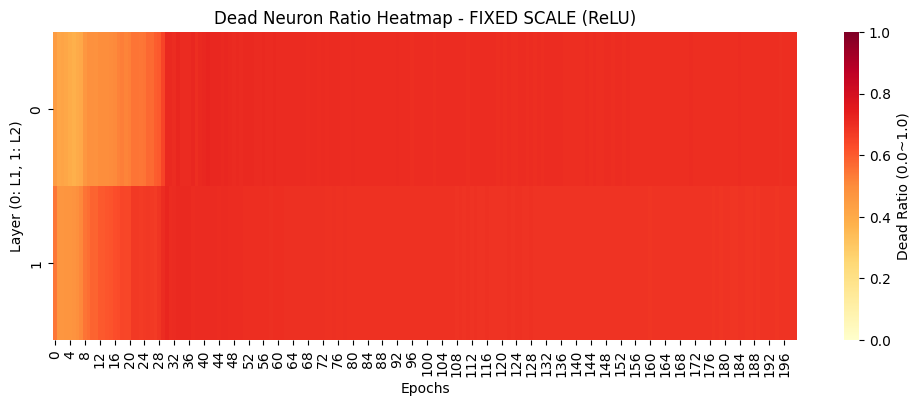

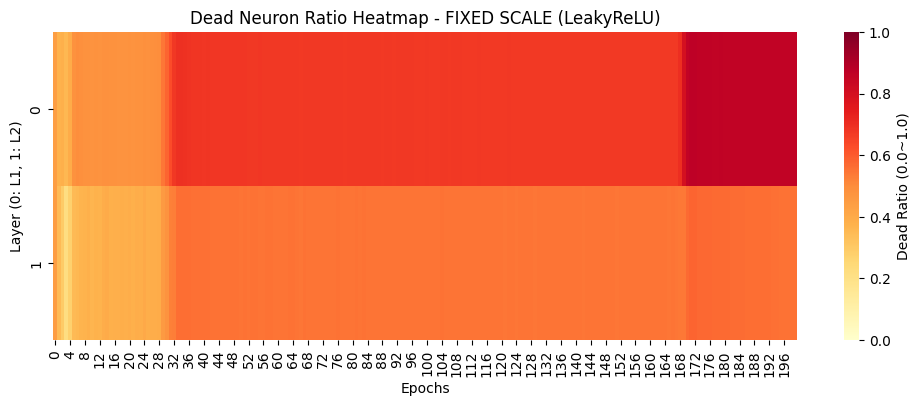

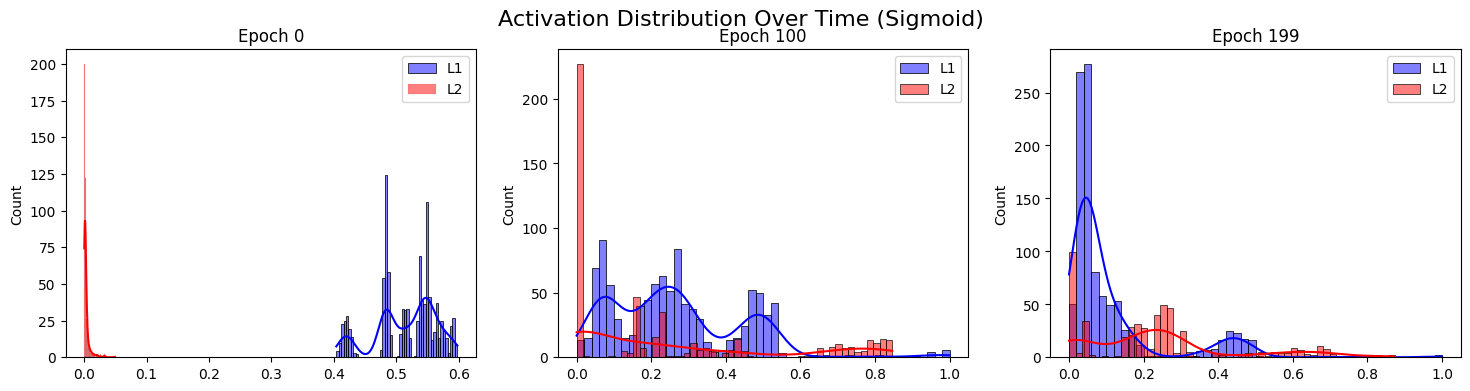

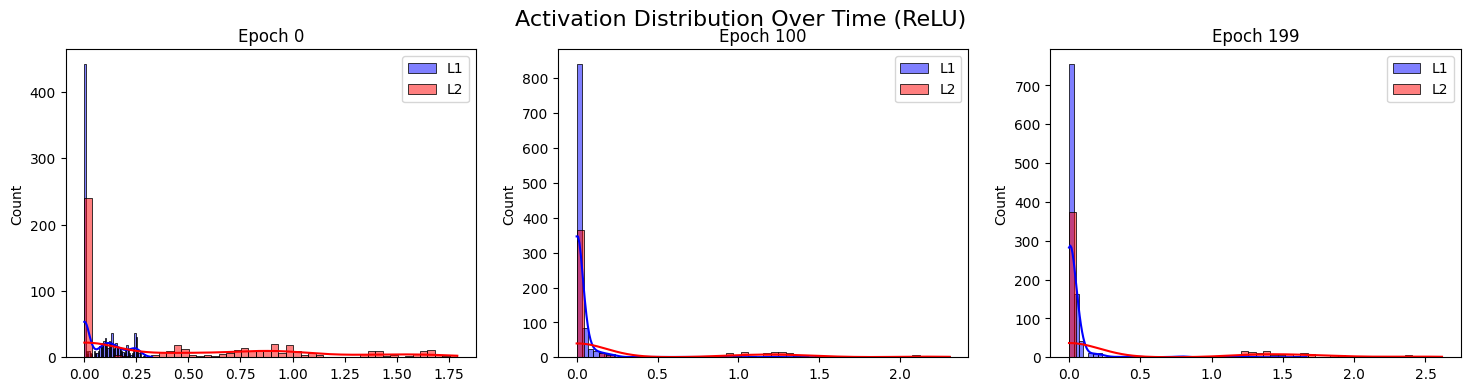

In [2]:
# 1. 시각화: Accuracy 비교
plt.figure(figsize=(10, 5))
for name, hist in results.items():
    plt.plot(hist['acc'], label=name)
plt.title('Accuracy Comparison by Activation Function')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

# 절대적인 비교를 위해 범위를 0 ~ 1로 고정합니다.
def plot_fixed_heatmap(name):
    dead_data = np.array(results[name]['dead_ratio']).T
    plt.figure(figsize=(12, 4))

    # vmin=0, vmax=1 설정을 통해 색상 기준을 통일합니다.
    sns.heatmap(dead_data, annot=False, cmap='YlOrRd', vmin=0, vmax=1, cbar_kws={'label': 'Dead Ratio (0.0~1.0)'})

    plt.title(f'Dead Neuron Ratio Heatmap - FIXED SCALE ({name})')
    plt.xlabel('Epochs')
    plt.ylabel('Layer (0: L1, 1: L2)')
    plt.show()

plot_fixed_heatmap('ReLU')
plot_fixed_heatmap('LeakyReLU')

# 3. 활성화 값 분포 히스토그램 (Sigmoid의 Vanishing 확인용)
def plot_activation_hist(name):
    hist_data = results[name]['activations']
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f'Activation Distribution Over Time ({name})', fontsize=16)

    for i, data in enumerate(hist_data):
        sns.histplot(data['layer1'].flatten(), bins=50, ax=axes[i], kde=True, color='blue', alpha=0.5, label='L1')
        sns.histplot(data['layer2'].flatten(), bins=50, ax=axes[i], kde=True, color='red', alpha=0.5, label='L2')
        axes[i].set_title(f"Epoch {data['epoch']}")
        axes[i].legend()
    plt.show()

plot_activation_hist('Sigmoid')
plot_activation_hist('ReLU')

In [3]:
import pandas as pd

def get_quantitative_analysis_b(results):
    summary_list = []

    for name, hist in results.items():
        # 1. 최종 성능 및 최고 성능
        final_acc = hist['acc'][-1]
        best_acc = max(hist['acc'])

        # 2. Dead Neuron Ratio (마지막 에폭 기준 평균)
        # Sigmoid는 구조상 'Dead' 개념이 아니므로 제외
        if name != 'Sigmoid':
            dead_ratio = np.mean(hist['dead_ratio'][-1]) * 100
            dead_str = f"{dead_ratio:.2f}%"
        else:
            dead_str = "N/A (Saturation)"

        # 3. 수렴 속도 지표 (정확도 80% 달성 시점)
        threshold = 80.0
        try:
            conv_epoch = next(i for i, v in enumerate(hist['acc']) if v >= threshold)
        except StopIteration:
            conv_epoch = "달성 실패"

        summary_list.append({
            '활성화 함수': name,
            '사멸 뉴런 비율 (Dead)': dead_str,
            '80% 도달 속도 (Epoch)': conv_epoch
        })

    # 표 생성
    df = pd.DataFrame(summary_list)

    print("\n" + "="*50)
    print(" [실험 B: 정량적 분석 요약 표] ")
    print("="*50)
    print(df.to_string(index=False))
    print("="*50)

    return df

# 분석 실행
analysis_df = get_quantitative_analysis_b(results)


 [실험 B: 정량적 분석 요약 표] 
   활성화 함수  사멸 뉴런 비율 (Dead)  80% 도달 속도 (Epoch)
     ReLU           69.37%                  0
LeakyReLU           70.58%                  0
  Sigmoid N/A (Saturation)                  3


실험 B 시작: 활성화 함수 = ReLU | Gradient Clipping = None
실험 B 시작: 활성화 함수 = ReLU | Gradient Clipping = 1.0


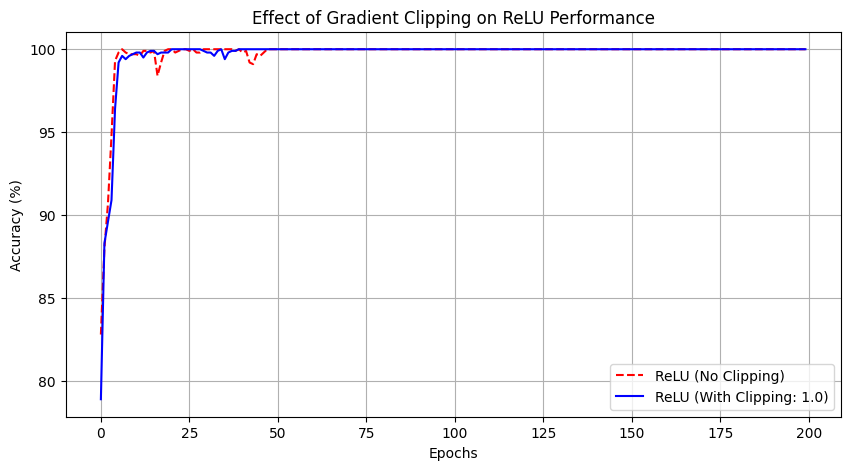

In [4]:
import torch.nn.utils as utils # 기울기 클리핑을 위한 유틸리티 임포트

# 3. 실험 실행 함수 (기울기 클리핑 옵션 추가)
def run_experiment_b_with_clipping(act_name, clip_value=None):
    print(f"실험 B 시작: 활성화 함수 = {act_name} | Gradient Clipping = {clip_value}")
    model = ActivationExpModel(act_name)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    history = {'acc': [], 'dead_ratio': [], 'activations': []}

    for epoch in range(200):
        model.train()
        correct = 0
        total = 0
        epoch_dead_counts = []

        for inputs, targets in loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()

            # --- 개선 사항 추가 Gradient Clipping 적용 ---
            if clip_value is not None:
                # 모델 파라미터의 L2 Norm이 clip_value를 넘지 않도록 제한
                utils.clip_grad_norm_(model.parameters(), max_norm=clip_value)
            # ---------------------------------------------

            optimizer.step()

            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

            with torch.no_grad():
                dead1 = (model.a1 <= 0).float().mean().item()
                dead2 = (model.a2 <= 0).float().mean().item()
                epoch_dead_counts.append([dead1, dead2])

        acc = 100. * correct / total
        history['acc'].append(acc)
        history['dead_ratio'].append(np.mean(epoch_dead_counts, axis=0))

        if epoch in [0, 100, 199]:
            history['activations'].append({
                'epoch': epoch,
                'layer1': model.a1.detach().cpu().numpy(),
                'layer2': model.a2.detach().cpu().numpy()
            })

    return history

# 4. 비교 실험 실행 (ReLU vs ReLU + Clipping)
results_clip = {
    'ReLU_No_Clip': run_experiment_b_with_clipping('ReLU', clip_value=None),
    'ReLU_With_Clip': run_experiment_b_with_clipping('ReLU', clip_value=1.0) # 임계값 1.0 적용
}

# 5. 결과 시각화: Accuracy 비교
plt.figure(figsize=(10, 5))
plt.plot(results_clip['ReLU_No_Clip']['acc'], label='ReLU (No Clipping)', color='red', linestyle='--')
plt.plot(results_clip['ReLU_With_Clip']['acc'], label='ReLU (With Clipping: 1.0)', color='blue')
plt.title('Effect of Gradient Clipping on ReLU Performance')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

실험 진행 중: ReLU (No Clipping)...
실험 B 시작: 활성화 함수 = ReLU | Gradient Clipping = None
실험 진행 중: ReLU (With Clipping)...
실험 B 시작: 활성화 함수 = ReLU | Gradient Clipping = 1.0


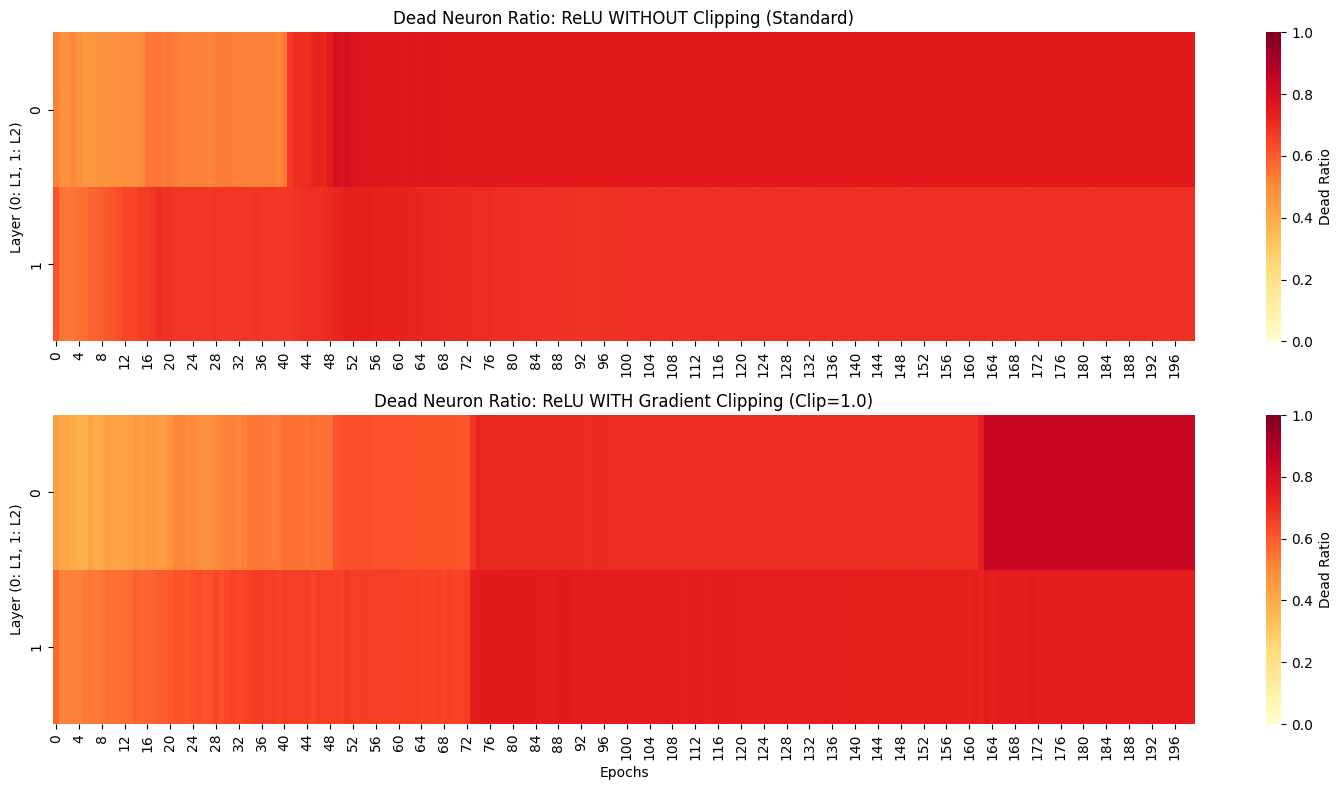

In [5]:
# --- 실험 실행: 클리핑 미적용 vs 적용 ---
print("실험 진행 중: ReLU (No Clipping)...")
res_no_clip = run_experiment_b_with_clipping('ReLU', clip_value=None)

print("실험 진행 중: ReLU (With Clipping)...")
res_clip = run_experiment_b_with_clipping('ReLU', clip_value=1.0)

# --- 히트맵 비교 시각화 함수 ---
def plot_clipping_comparison_heatmap(res_no, res_with):
    fig, axes = plt.subplots(2, 1, figsize=(15, 8))

    # 1. No Clipping 히트맵
    dead_data_no = np.array(res_no['dead_ratio']).T
    sns.heatmap(dead_data_no, ax=axes[0], cmap='YlOrRd', vmin=0, vmax=1,
                cbar_kws={'label': 'Dead Ratio'})
    axes[0].set_title('Dead Neuron Ratio: ReLU WITHOUT Clipping (Standard)')
    axes[0].set_ylabel('Layer (0: L1, 1: L2)')

    # 2. With Clipping 히트맵
    dead_data_with = np.array(res_with['dead_ratio']).T
    sns.heatmap(dead_data_with, ax=axes[1], cmap='YlOrRd', vmin=0, vmax=1,
                cbar_kws={'label': 'Dead Ratio'})
    axes[1].set_title('Dead Neuron Ratio: ReLU WITH Gradient Clipping (Clip=1.0)')
    axes[1].set_ylabel('Layer (0: L1, 1: L2)')
    axes[1].set_xlabel('Epochs')

    plt.tight_layout()
    plt.show()

# 실행
plot_clipping_comparison_heatmap(res_no_clip, res_clip)